## Imports das Bibliotecas

In [15]:
## Imports Geral
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import nltk
import numpy as np 

# Import para Visualização de Dados
from wordcloud import WordCloud

# Extração de Texto
from nltk.corpus import stopwords

# Importações de Metrica
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Modelos
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings

# Suprimir todos os warnings
warnings.filterwarnings("ignore")

# DESENVOLVER O MODELO SEM VIES 

# Analise dos dados

In [16]:
df1 = pd.read_csv("./datasets/Coleta_Brancas.csv")
df2 = pd.read_csv("./datasets/Coleta_Negras.csv")
df3 = pd.read_csv("./datasets/Coleta_Pardas.csv")

df = pd.concat([df1, df2, df3])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1226 entries, 0 to 370
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           1226 non-null   object
 1   Original_Text  1226 non-null   object
 2   Cor            1226 non-null   object
 3   Conclusao      359 non-null    object
dtypes: object(4)
memory usage: 47.9+ KB


In [18]:
df = df.rename(columns={'Name': 'name', 'Original_Text':'ementa' , 'Cor': 'cor', 'Conclusao': 'conclusao'})
df['conclusao'] = df['conclusao'].fillna('VAZIO')
df

,name,ementa,cor,conclusao
0,Adilson Candido Da Silva,\nExcelentíssimo(a) Senhor(a) Doutor(a) Juiz(a...,Branca,VAZIO
1,Adilson Candido Da Silva,EXCELENTÍSSIMO SENHOR DOUTOR JUIZ FEDERAL DA ...,Branca,VAZIO
2,Adilson Candido Da Silva,EXCELENTÍSSIMO SENHOR DOUTOR JUIZ DE DIREITO ...,Branca,VAZIO
3,Adilson Candido Da Silva,\nFls.: 2\nEXCELENTÍSSIMO SENHOR DOUTOR JUIZ D...,Branca,GANHO
4,Adilson Candido Da Silva,EXMO. SR. DR. JUIZ DE DIREITO DA 7º VARA CÍVE...,Branca,PERDIDO
...,...,...,...,...
366,Weber Lasaro De Oliveira,\nEXCELENTÍSSIMO SENHOR DOUTOR JUIZ FEDERAL DA...,Parda,AMBIGUO
367,Weber Lasaro De Oliveira,\nEXCELENTÍSSIMO SENHOR DOUTOR JUIZ FEDERAL DA...,Parda,AMBIGUO
368,Wilson Jose De Araujo,AO JUÍZO DE DIREITO DA VARA DO JUIZADO ESPECI...,Parda,VAZIO
369,Wilson Jose De Araujo,\nEXCELENTÍSSIMA SENHORA DOUTORA JUÍZA DE DIRE...,Parda,PERDIDO


In [21]:
# Remova duplicatas apenas da coluna A e concatene os valores correspondentes em uma única instância
df = df.groupby('name').agg(lambda x: ', '.join(x.unique())).reset_index()

In [22]:
df['cor'].value_counts()

cor
Branca    86
Parda     56
Negra     23
Name: count, dtype: int64

In [23]:
# # y_pred = model_LR.predict(X)
# # rng = np.random.default_rng(42)
# rng = np.random.default_rng(62)
# numbers = rng.random(len(df))
# balanceamento = [df.loc[df["cor"] == "BRANCA"].sample(1)  if i < prob_brancos else df.loc[df['cor'] == 'OUTROS'].sample(1) for i in numbers]
# df = pd.concat(balanceamento)


In [24]:
# df["nome"].value_counts().unique()
df["ementa"].count()

165

In [25]:
cor = df["cor"].value_counts().reset_index()
cor["cor"].unique()
cor

,cor,count
0,Branca,86
1,Parda,56
2,Negra,23


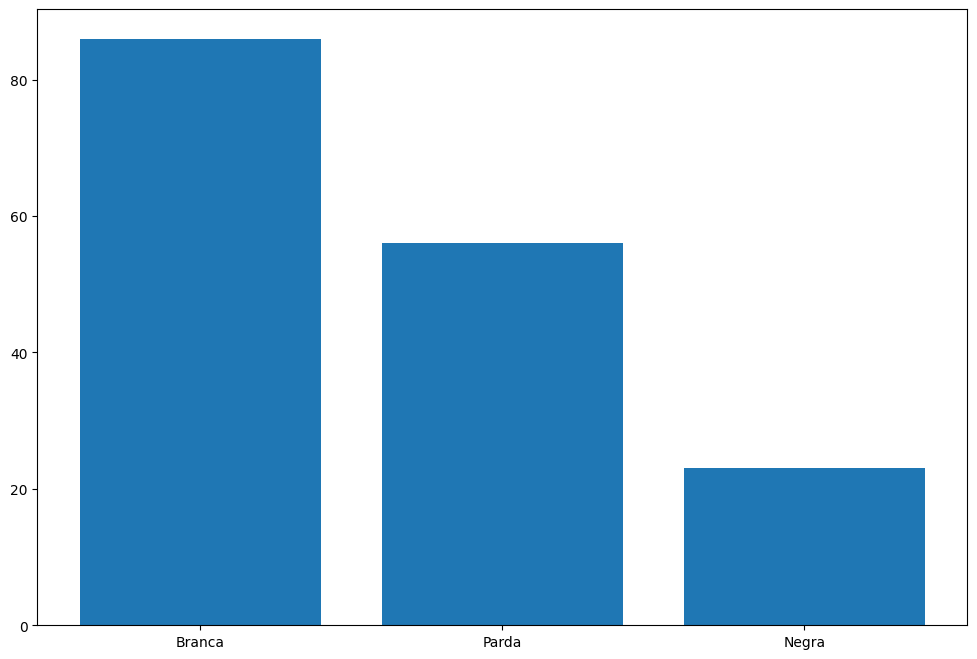

In [26]:
fx, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.bar(cor["cor"], height=cor["count"])
plt.show()

In [27]:
df["ementa"].dropna().count()

165

## Bag Of Words

In [28]:
# nltk.download('stopwords')

In [29]:
df = df.dropna(subset=["ementa"]).reset_index(drop=True)

In [30]:
tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
X = tf_idf.fit_transform(df["ementa"])
vocab = tf_idf.get_feature_names_out()
vocab = ' '.join(vocab)


## WORD CLOUD

In [31]:
le = LabelEncoder()

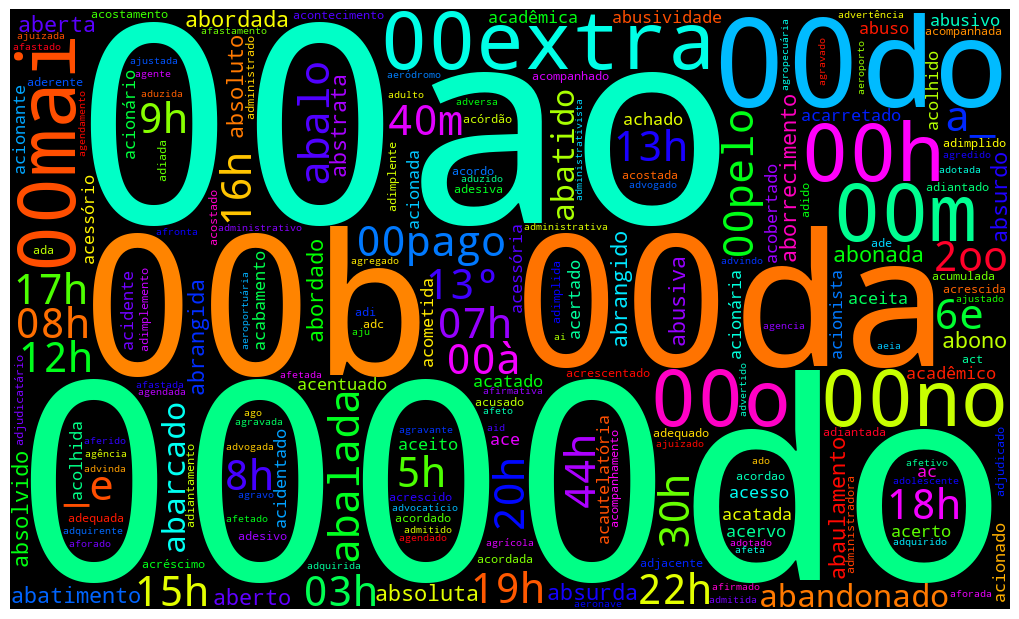

In [32]:
# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='gist_rainbow',
    min_font_size=10).generate(vocab)

plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [35]:
le = LabelEncoder()

df["cor"] = le.fit_transform(df["cor"])
y = df["cor"]

## Treino do Modelo

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
from imblearn.over_sampling import SMOTE

# transform the dataset
oversample = SMOTE()
X_train, y_train = oversample.fit_resample(X_train, y_train)

In [43]:
## Funçao para Avaliação dos Modelos

def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
                                "Branca", 'Pardos', 'Negros'])
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

In [44]:
#K Fold

K = 5
kf = KFold(n_splits=K, shuffle=False) 

# Logistic Regression

In [45]:
model_LR = LogisticRegression(random_state=42, max_iter=1000, solver="liblinear", penalty="l2", C=3, tol=0.001)
cross_val_results = cross_val_score(model_LR, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_LR, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)


print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.29112834 0.25660699 0.4057623  0.1969697  0.1300813 ]
Media da Accuracy:  0.4303030303030303
Media da MACRO F1:  0.25610972619339506
Desvio Padrão da MACRO F1:  0.09273958356614477


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.52      0.69      0.59        16
           1       0.00      0.00      0.00         3
           2       0.25      0.07      0.11        14

    accuracy                           0.36        33
   macro avg       0.26      0.25      0.24        33
weighted avg       0.36      0.36      0.34        33



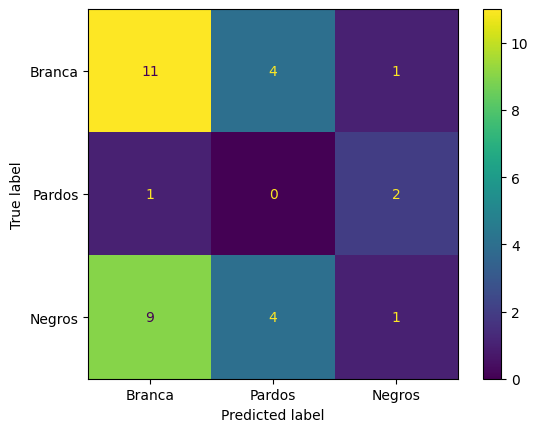

In [46]:
model_LR.fit(X_train, y_train)
y_pred = model_LR.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

# SGD Classifier

In [47]:
model_SGD = SGDClassifier(random_state=42, loss="squared_hinge", alpha=0.0001, learning_rate="constant", eta0=0.1, power_t=0.5, penalty="l2", tol=0.001, early_stopping=True, n_jobs=-1, class_weight="balanced")
cross_val_results = cross_val_score(model_SGD, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_SGD, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.27017544 0.15789474 0.32640333 0.225      0.14035088]
Media da Accuracy:  0.35757575757575755
Media da MACRO F1:  0.22396487580698105
Desvio Padrão da MACRO F1:  0.06926281510747002


# K Neighbors Classifier

In [48]:
model_KNeighbors = KNeighborsClassifier(n_neighbors=5, weights="distance", algorithm="auto", leaf_size=50, p=2 )
cross_val_results = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="f1_macro", )
cross_val_results_accuracy = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.20952381 0.13793103 0.1087344  0.25238095 0.15584416]
Media da Accuracy:  0.2
Media da MACRO F1:  0.17288287101674524
Desvio Padrão da MACRO F1:  0.05155478246482405


Classification Report for Data Test
              precision    recall  f1-score   support

           0       1.00      0.06      0.12        16
           1       0.08      0.67      0.14         3
           2       0.14      0.07      0.10        14

    accuracy                           0.12        33
   macro avg       0.41      0.27      0.12        33
weighted avg       0.55      0.12      0.11        33



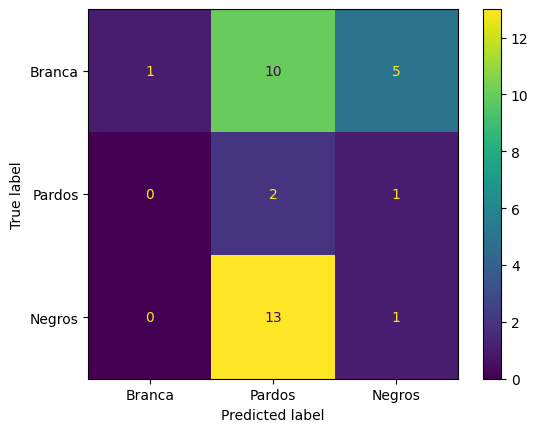

In [49]:
model_KNeighbors.fit(X_train, y_train)
y_pred = model_KNeighbors.predict(X_test)
evaluation_parametrics("Machine Learning - K Neighbors", y_test, y_pred)

# SVM (SUPPORT VECTOR MACHINE)

In [50]:
model_SVM = LinearSVC(random_state=42, loss='squared_hinge', max_iter=1000, penalty="l2", C=3, tol=0.0001, multi_class='ovr', dual=True, class_weight="balanced",  )
cross_val_results = cross_val_score(model_SVM, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_SVM, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.30555556 0.21937984 0.21779254 0.17886179 0.15511163]
Media da Accuracy:  0.3696969696969697
Media da MACRO F1:  0.21534027317622476
Desvio Padrão da MACRO F1:  0.05122362312915924


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.46      0.69      0.55        16
           1       0.00      0.00      0.00         3
           2       0.40      0.14      0.21        14

    accuracy                           0.39        33
   macro avg       0.29      0.28      0.25        33
weighted avg       0.39      0.39      0.36        33



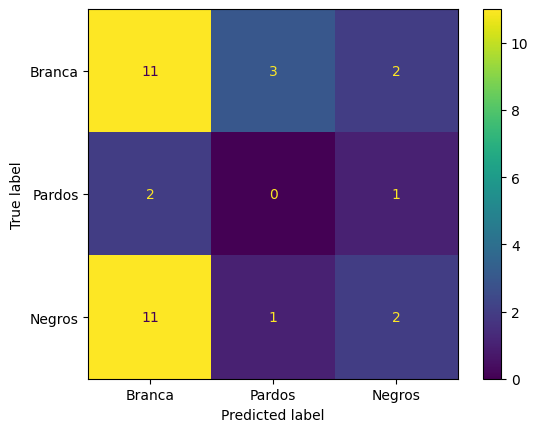

In [51]:
model_SVM.fit(X_train, y_train)
y_pred = model_SVM.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest

In [52]:
model_Random_Forest = RandomForestClassifier(random_state=42, n_estimators=500, criterion="gini", max_features='sqrt', class_weight='balanced', n_jobs=-1, )
cross_val_results = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="accuracy")


print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.21276596 0.31701632 0.37735849 0.28684003 0.1300813 ]
Media da Accuracy:  0.48484848484848475
Media da MACRO F1:  0.2648124194726108
Desvio Padrão da MACRO F1:  0.08571859690235355


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.52      0.81      0.63        16
           1       0.00      0.00      0.00         3
           2       0.38      0.21      0.27        14

    accuracy                           0.48        33
   macro avg       0.30      0.34      0.30        33
weighted avg       0.41      0.48      0.42        33



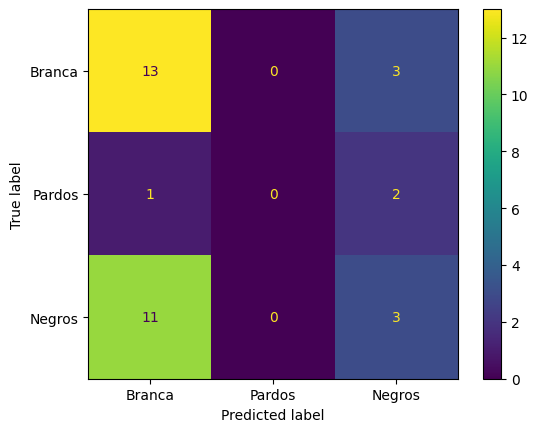

In [53]:
model_Random_Forest.fit(X_train, y_train)
y_pred = model_Random_Forest.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

# Decision Tree

In [54]:
model_Decision_Tree = DecisionTreeClassifier(random_state=42, criterion="entropy", splitter="random", class_weight="balanced", ccp_alpha=0.0001)

cross_val_results = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.29043928 0.19023569 0.27910686 0.11507937 0.35446793]
Media da Accuracy:  0.3515151515151515
Media da MACRO F1:  0.24586582343634586
Desvio Padrão da MACRO F1:  0.08376871191334548


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.58      0.69      0.63        16
           1       0.00      0.00      0.00         3
           2       0.54      0.50      0.52        14

    accuracy                           0.55        33
   macro avg       0.37      0.40      0.38        33
weighted avg       0.51      0.55      0.52        33



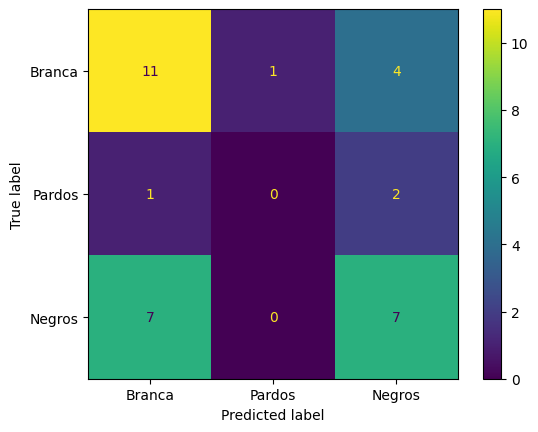

In [55]:
model_Decision_Tree.fit(X_train, y_train)
y_pred = model_Decision_Tree.predict(X_test)
evaluation_parametrics("Machine Learning - Decision Tree", y_test, y_pred)

In [56]:
## Funçao para Avaliação dos Modelos
# Refazer essa parte 
import numpy as np

branca:int = df["cor"].loc[(df["cor"] == 0)].value_counts()
# print(int(branca))
prob_brancos = (int(branca)/len(df["cor"]))

outros:int = df["cor"].loc[(df["cor"] == 1)].value_counts()

prob_outros = (int(outros)/len(df["cor"]))

rng = np.random.default_rng(62)
numbers = rng.random(len(y_test))


balanceamento = [df.loc[df["cor"] == 0].sample(1)  if i < prob_brancos else df.loc[df['cor'] == 1].sample(1) for i in numbers]
df = pd.concat(balanceamento)


from sklearn.metrics import f1_score

f1_score(y_test, df['cor'], average='macro')

0.19393939393939394